<a href="https://colab.research.google.com/github/muniznicole/coleta_e_analise_de_emails/blob/main/coleta_e_analise_de_emails.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ETAPA 1: COLETA DE DADOS

In [ ]:
# Montar o drive
from google.colab import drive
drive.mount('/content/drive')

# Carregar o arquivo CSV diretamente
import pandas as pd
df_2021 = pd.read_csv('/content/drive/MyDrive/Coleta_de_emails_Nicole/Coleta_de_emails_SuporteDTI_completa/Coleta_de_emails_SuporteDTI2021.csv')
df_2022 = pd.read_csv('/content/drive/MyDrive/Coleta_de_emails_Nicole/Coleta_de_emails_SuporteDTI_completa/Coleta_de_emails_SuporteDTI2022.csv')
df_2023 = pd.read_csv('/content/drive/MyDrive/Coleta_de_emails_Nicole/Coleta_de_emails_SuporteDTI_completa/Coleta_de_emails_SuporteDTI2023.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# ETAPA 2: PRÉ-PROCESSAMENTO DOS DADOS E TÓPICOS FREQUENTES

In [ ]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Downloads necessários para NLTK
nltk.download('punkt')
nltk.download('stopwords')

# Carregar stopwords em português e adicionar mais palavras irrelevantes para e-mails
stop_words = set(stopwords.words('portuguese'))
stop_words.update([
    'boa', 'bom', 'tarde', 'dia', 'olá', 'prezados', '-', ',', '.', '!', '?',
    'sr', 'sra', 'senhor', 'senhora', 'atenciosamente', 'unitins', 'br', 'fwd', 're',
    'http', 'https', 'att', 'message', 'forwarded', 'image', 'rogerio', 'rogério', 'lopes', 'ferreira',
    'subject', 'universidade', 'estadual', 'tocantins', 'para', 'de', 'do', 'da', 'em', 'ao',
    'no', 'na', 'por', 'e', 'a', 'o', 'que', 'é', 'foi', 'enviado', 'email', 'e-mail',
    'assunto', 'corpo', 'caro', 'caros', 'envio', 'recebido', 'segue', 'anexo', 'solicitação',
    'gentileza', 'por favor', 'favor', 'sistema', 'destinatário', 'remetente', 'usuário', 'conta',
    'data', 'hora', 'respondido', 'problema', 'error', 'erro', 'necessário', 'resposta', 'solução', 'por gentileza',
    'glpi', 'gostaria', 'solicito', 'preciso', 'pois', 'desde', 'agradeço', 'direitos', 'reservados',
    'novo', 'chamado', 'acominho', 'browser', 'cancelar', 'subscrição', 'web', 'site',
    'dti', 'suporte', 'sistemas', 'institucional'
])

# Função de pré-processamento para remover stopwords e pontuações
def preprocess(text):
    if isinstance(text, str):  # Verifica se o texto é uma string
        # Tokenizar
        tokens = word_tokenize(text.lower())
        # Remover stopwords e manter apenas palavras alfabéticas
        tokens = [word for word in tokens if word.isalpha() and word not in stop_words]
        return ' '.join(tokens)
    else:
        return ''  # Retorna uma string vazia para valores não-string

# Remover linhas com a palavra "acominho" no assunto ou corpo e aplicar pré-processamento
for i, df in enumerate([df_2021, df_2022, df_2023]):
    # Filtrar linhas que NÃO contêm "acominho"
    df = df[~df['Assunto'].str.contains(r'\bacominho\b', case=False, na=False)]
    df = df[~df['Corpo do E-mail (Resumo)'].str.contains(r'\bacominho\b', case=False, na=False)]

    # Remover linhas com dados faltantes nas colunas de interesse
    df.dropna(subset=['Assunto', 'Corpo do E-mail (Resumo)'], inplace=True)

    # Criar as colunas de texto processado
    df['processed_subject'] = df['Assunto'].apply(preprocess)
    df['processed_body'] = df['Corpo do E-mail (Resumo)'].apply(preprocess)

    # Atualizar o DataFrame original
    if i == 0:
        df_2021 = df
    elif i == 1:
        df_2022 = df
    elif i == 2:
        df_2023 = df

# Análise de Tópicos com KMeans usando TF-IDF
def analyze_topics_kmeans(df, num_clusters=5):
    # Juntar textos de assunto e corpo do e-mail já processados
    df['combined_text'] = df['processed_subject'] + " " + df['processed_body']

    # Criar vetor TF-IDF sem stopwords, pois elas já foram removidas
    vectorizer = TfidfVectorizer(max_df=0.5, min_df=2)
    tfidf_matrix = vectorizer.fit_transform(df['combined_text'])

    # Aplicar KMeans para agrupar os tópicos
    kmeans = KMeans(n_clusters=num_clusters, random_state=42)
    kmeans.fit(tfidf_matrix)

    # Associar os clusters aos e-mails
    df['cluster'] = kmeans.labels_

    return kmeans, vectorizer, tfidf_matrix, df

# Aplicar a função para cada ano
kmeans_2021, vectorizer_2021, tfidf_2021, df_2021 = analyze_topics_kmeans(df_2021)
kmeans_2022, vectorizer_2022, tfidf_2022, df_2022 = analyze_topics_kmeans(df_2022)
kmeans_2023, vectorizer_2023, tfidf_2023, df_2023 = analyze_topics_kmeans(df_2023)

# Função para exibir os clusters e palavras associadas
def print_clusters(kmeans, vectorizer, num_words=5):
    terms = vectorizer.get_feature_names_out()
    for i, center in enumerate(kmeans.cluster_centers_):
        print(f"Cluster {i + 1}:")
        words = [terms[ind] for ind in center.argsort()[-num_words:]]
        print(", ".join(words))

print("\nTópicos para 2021:")
print_clusters(kmeans_2021, vectorizer_2021)

print("\nTópicos para 2022:")
print_clusters(kmeans_2022, vectorizer_2022)

print("\nTópicos para 2023:")
print_clusters(kmeans_2023, vectorizer_2023)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
<ipython-input-60-0d9560feb0df>:48: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.dropna(subset=['Assunto', 'Corpo do E-mail (Resumo)'], inplace=True)
<ipython-input-60-0d9560feb0df>:48: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.dropna(subset=['Assunto', 'Corpo do E-mail (Resumo)'], inplace=True)



Tópicos para 2021:
Cluster 1:
cpf, vestibular, curso, cadastro, inscrição
Cluster 2:
recuperação, nova, esqueci, recuperar, senha
Cluster 3:
cpf, palmas, câmpus, acesso, sgd
Cluster 4:
solicita, pasta, liberação, atualização, acesso
Cluster 5:
conseguindo, acesso, acessar, aluno, portal

Tópicos para 2022:
Cluster 1:
fazer, boleto, pagamento, vestibular, inscrição
Cluster 2:
aprove, reprove, tech, cadastro, cadun
Cluster 3:
acesso, acessar, portal, curso, aluno
Cluster 4:
cpf, servidora, criação, sgd, acesso
Cluster 5:
acesso, portal, esqueci, recuperar, senha

Tópicos para 2023:
Cluster 1:
cadun, fazer, alteração, cadastro, inscrição
Cluster 2:
acesso, conseguindo, acessar, aluno, portal
Cluster 3:
acessar, acesso, recuperação, recuperar, senha
Cluster 4:
liberação, biblioteca, pasta, sgd, acesso
Cluster 5:
graduado, disciplina, gestão, educa, curso


## Nuvem de palavras combinando os clusters por ano

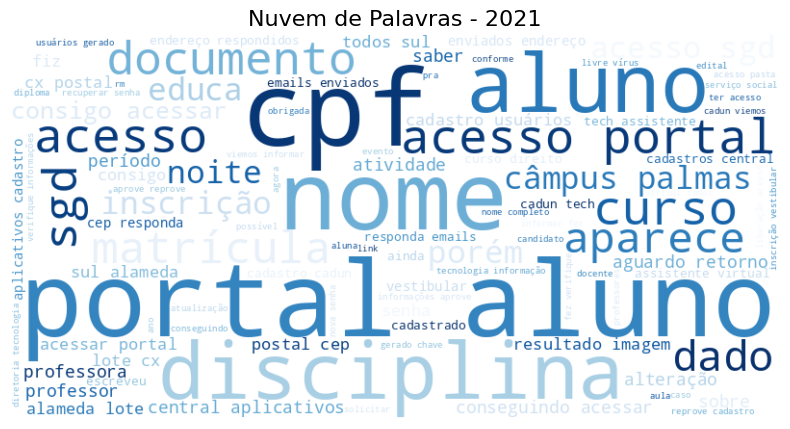

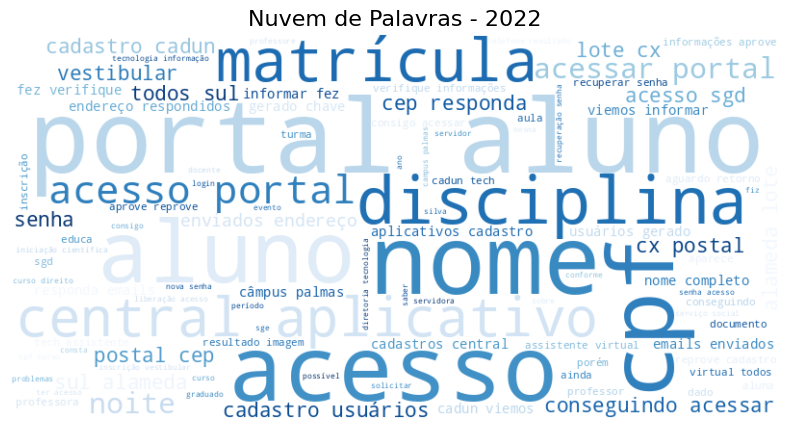

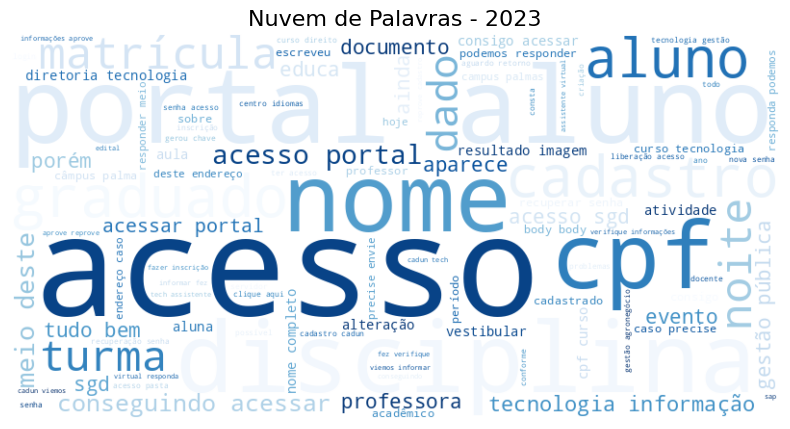

In [ ]:
# Importar as bibliotecas necessárias
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Função para gerar a nuvem de palavras por ano
def gerar_wordcloud_por_ano(df, ano):
    # Juntar todos os e-mails processados (assunto + corpo) em um único texto
    texto = ' '.join(df['processed_subject'].values) + ' ' + ' '.join(df['processed_body'].values)

    # Gerar a nuvem de palavras
    wordcloud = WordCloud(width=800, height=400, background_color='white', max_words=100, colormap='Blues').generate(texto)

    # Plotar a nuvem de palavras
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Nuvem de Palavras - {ano}', fontsize=16)
    plt.show()

# Exemplo de chamada para gerar as nuvens para os anos de 2021, 2022 e 2023
# df_2021, df_2022, df_2023 são os DataFrames que contêm os dados dos respectivos anos,
# com as colunas 'processed_subject' e 'processed_body' já processadas.

gerar_wordcloud_por_ano(df_2021, 2021)
gerar_wordcloud_por_ano(df_2022, 2022)
gerar_wordcloud_por_ano(df_2023, 2023)

# ETAPA 3: IDENTIFICAÇÃO DOS PROBLEMAS RECORRENTES

In [ ]:
from collections import Counter

def extrair_topicos_por_cluster(df, vectorizer, kmeans, num_palavras=5):
    """
    Extrai as palavras mais relevantes de cada cluster.
    """
    termos = vectorizer.get_feature_names_out()
    topicos_por_cluster = []

    # Iterar pelos clusters e extrair as palavras mais importantes
    for i in range(kmeans.n_clusters):
        palavras_cluster = [termos[ind] for ind in kmeans.cluster_centers_[i].argsort()[-num_palavras:]]
        topicos_por_cluster.extend(palavras_cluster)

    return topicos_por_cluster

# Aplicar a extração para cada ano
topicos_2021 = extrair_topicos_por_cluster(df_2021, vectorizer_2021, kmeans_2021)
topicos_2022 = extrair_topicos_por_cluster(df_2022, vectorizer_2022, kmeans_2022)
topicos_2023 = extrair_topicos_por_cluster(df_2023, vectorizer_2023, kmeans_2023)

# Unir os tópicos de todos os anos
todos_topicos = topicos_2021 + topicos_2022 + topicos_2023

# Contar a frequência das palavras e obter os 10 principais tópicos
from collections import Counter

frequencia_topicos = Counter(todos_topicos)
principais_problemas = frequencia_topicos.most_common(10)

# Exibir os 10 principais problemas
print("Os 10 principais problemas considerando os 3 anos:")
for problema, freq in principais_problemas:
    print(f"{problema}: {freq} ocorrências")

Os 10 principais problemas considerando os 3 anos:
acesso: 9 ocorrências
acessar: 4 ocorrências
portal: 4 ocorrências
cpf: 3 ocorrências
curso: 3 ocorrências
cadastro: 3 ocorrências
inscrição: 3 ocorrências
recuperar: 3 ocorrências
senha: 3 ocorrências
sgd: 3 ocorrências


## Nuvem de palavras dos principais problemas

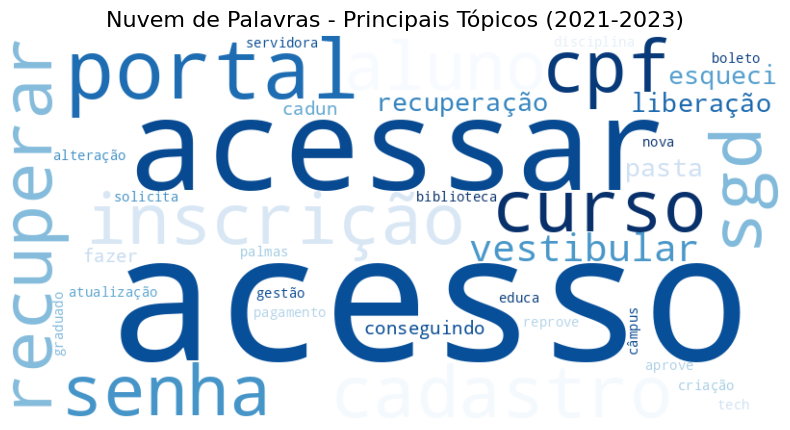

In [ ]:
# Importar as bibliotecas necessárias
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from collections import Counter

# Função para gerar a nuvem de palavras com base nos tópicos frequentes
def gerar_wordcloud_topicos(frequencia_topicos):
    # Gerar a nuvem de palavras baseada na frequência
    wordcloud = WordCloud(width=800, height=400, background_color='white', max_words=100, colormap='Blues').generate_from_frequencies(frequencia_topicos)

    # Plotar a nuvem de palavras
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title('Nuvem de Palavras - Principais Tópicos (2021-2023)', fontsize=16)
    plt.show()

# Aplicar a função para gerar a nuvem de palavras dos tópicos mais comuns
gerar_wordcloud_topicos(frequencia_topicos)

# ETAPA 4: ANÁLISE DOS DADOS OBTIDOS

## ANÁLISE DE CONTEXTO

In [ ]:
def encontrar_coocorrencias_global(dfs, palavra_alvo, frequencia_minima=3):
    """
    Encontra as palavras mais comuns que aparecem junto com a palavra-alvo
    considerando os dados dos três anos combinados.
    """
    coocorrencias = Counter()

    # Iterar por todas as entradas dos três anos combinados
    for df in dfs:
        for texto in df['combined_text']:
            palavras = texto.split()
            if palavra_alvo in palavras:
                # Adicionar palavras relevantes, excluindo stopwords
                palavras_filtradas = [p for p in palavras if p not in stop_words and p != palavra_alvo]
                coocorrencias.update(palavras_filtradas)

    # Retornar no máximo 5 palavras mais comuns que co-ocorrem com a palavra-alvo
    return coocorrencias.most_common(5)

def encontrar_problemas_com_contexto_global(principais_problemas, dfs):
    """
    Identifica os principais problemas e mostra o contexto relevante considerando
    todos os anos combinados.
    """
    print("Principais problemas com contexto (Análise Global):")
    for palavra, freq in principais_problemas:
        print(f"\nProblema: {palavra} ({freq} ocorrências)")
        contexto = encontrar_coocorrencias_global(dfs, palavra)
        print("Contexto:", contexto)

# Consolidar os DataFrames dos três anos
dfs = [df_2021, df_2022, df_2023]

# Aplicar a análise de contexto global
encontrar_problemas_com_contexto_global(principais_problemas, dfs)

Principais problemas com contexto (Análise Global):

Problema: acesso (9 ocorrências)
Contexto: [('senha', 1550), ('cpf', 1483), ('portal', 1185), ('curso', 1138), ('aluno', 957)]

Problema: acessar (4 ocorrências)
Contexto: [('senha', 1022), ('acesso', 999), ('portal', 927), ('aluno', 753), ('cpf', 604)]

Problema: portal (4 ocorrências)
Contexto: [('aluno', 1500), ('acesso', 1217), ('senha', 994), ('acessar', 736), ('curso', 732)]

Problema: cpf (3 ocorrências)
Contexto: [('acesso', 2176), ('senha', 1258), ('curso', 1098), ('nome', 1074), ('portal', 901)]

Problema: curso (3 ocorrências)
Contexto: [('acesso', 1328), ('cpf', 1029), ('portal', 876), ('aluno', 806), ('nome', 782)]

Problema: cadastro (3 ocorrências)
Contexto: [('cadun', 753), ('acesso', 569), ('cpf', 527), ('endereço', 466), ('senha', 417)]

Problema: inscrição (3 ocorrências)
Contexto: [('vestibular', 638), ('fazer', 365), ('pagamento', 283), ('curso', 274), ('cpf', 253)]

Problema: recuperar (3 ocorrências)
Contexto: 

## COOCORRÊNCIAS DE CADA PROBLEMA

In [ ]:
import pandas as pd

def exibir_contexto_tabela(contexto, palavra_alvo):
    # Converter contexto em um DataFrame
    contexto_df = pd.DataFrame(contexto, columns=['Palavra', 'Frequência'])
    contexto_df['Palavra-Alvo'] = palavra_alvo

    # Exibir a tabela
    print(contexto_df)

def encontrar_problemas_com_contexto_global(principais_problemas, dfs):
    """
    Identifica os principais problemas e mostra o contexto relevante considerando
    todos os anos combinados.
    """
    print("Principais problemas com contexto (Análise Global):")
    for palavra, freq in principais_problemas:
        print(f"\nProblema: {palavra} ({freq} ocorrências)")
        contexto = encontrar_coocorrencias_global(dfs, palavra)

        # Exibir o contexto em forma de tabela
        exibir_contexto_tabela(contexto, palavra)

# Consolidar os DataFrames dos três anos
dfs = [df_2021, df_2022, df_2023]

# Aplicar a análise de contexto global
encontrar_problemas_com_contexto_global(principais_problemas, dfs)

Principais problemas com contexto (Análise Global):

Problema: acesso (9 ocorrências)
  Palavra  Frequência Palavra-Alvo
0   senha        1550       acesso
1     cpf        1483       acesso
2  portal        1185       acesso
3   curso        1138       acesso
4   aluno         957       acesso

Problema: acessar (4 ocorrências)
  Palavra  Frequência Palavra-Alvo
0   senha        1022      acessar
1  acesso         999      acessar
2  portal         927      acessar
3   aluno         753      acessar
4     cpf         604      acessar

Problema: portal (4 ocorrências)
   Palavra  Frequência Palavra-Alvo
0    aluno        1500       portal
1   acesso        1217       portal
2    senha         994       portal
3  acessar         736       portal
4    curso         732       portal

Problema: cpf (3 ocorrências)
  Palavra  Frequência Palavra-Alvo
0  acesso        2176          cpf
1   senha        1258          cpf
2   curso        1098          cpf
3    nome        1074          cpf
4  

# ANÁLISE DE SENTIMENTO

In [ ]:
from textblob import TextBlob

def analisar_sentimento(text):
    blob = TextBlob(text)
    polaridade = blob.sentiment.polarity  # Valor entre -1 (negativo) e 1 (positivo)
    return 'Positivo' if polaridade > 0 else 'Negativo' if polaridade < 0 else 'Neutro'

# Aplicar a análise de sentimento nas colunas de texto combinado
for df in [df_2021, df_2022, df_2023]:
    df['sentimento'] = df['combined_text'].apply(analisar_sentimento)

# Exibir distribuição de sentimentos por ano
for ano, df in zip([2021, 2022, 2023], [df_2021, df_2022, df_2023]):
    print(f"\nDistribuição de sentimentos em {ano}:")
    print(df['sentimento'].value_counts())


Distribuição de sentimentos em 2021:
sentimento
Neutro      3053
Positivo     224
Negativo      26
Name: count, dtype: int64

Distribuição de sentimentos em 2022:
sentimento
Neutro      3470
Positivo     181
Negativo      13
Name: count, dtype: int64

Distribuição de sentimentos em 2023:
sentimento
Neutro      3987
Positivo     331
Negativo      30
Name: count, dtype: int64


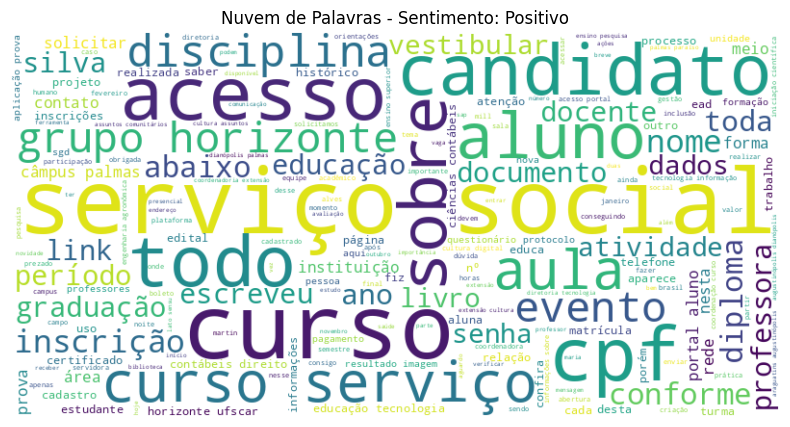

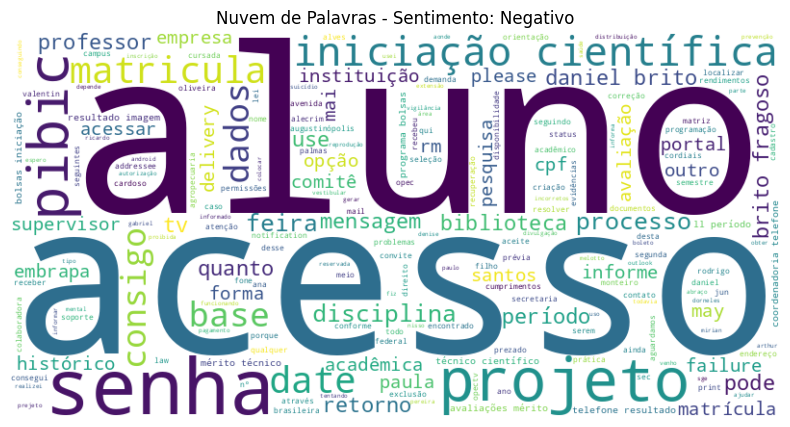

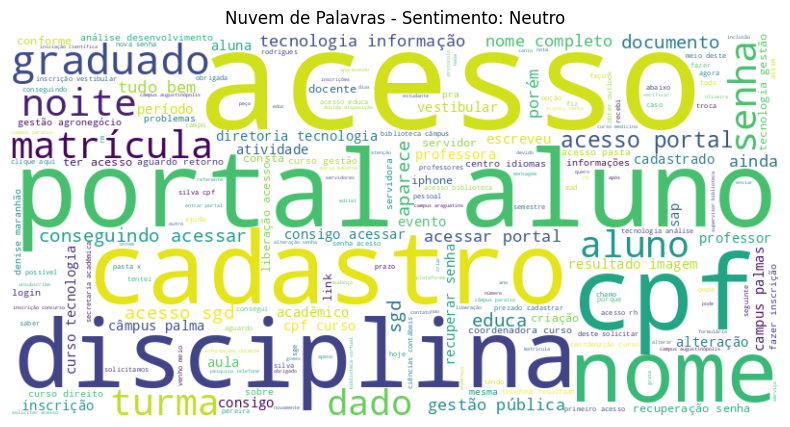

In [ ]:
def gerar_wordcloud_por_sentimento(df, sentimento):
    textos = df[df['sentimento'] == sentimento]['combined_text']
    texto_concatenado = ' '.join(textos)

    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(texto_concatenado)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Nuvem de Palavras - Sentimento: {sentimento}')
    plt.show()

# Exemplo: Gerar nuvem de palavras para sentimento positivo
gerar_wordcloud_por_sentimento(df_2021, 'Positivo')
gerar_wordcloud_por_sentimento(df_2022, 'Negativo')
gerar_wordcloud_por_sentimento(df_2023, 'Neutro')

#TENDÊNCIAS TEMPORAIS

<ipython-input-68-6c89aab65210>:3: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Data'] = pd.to_datetime(df['Data'])
<ipython-input-68-6c89aab65210>:3: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Data'] = pd.to_datetime(df['Data'])
<ipython-input-68-6c89aab65210>:3: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Data'] = pd.to_datetime(df['Data'])


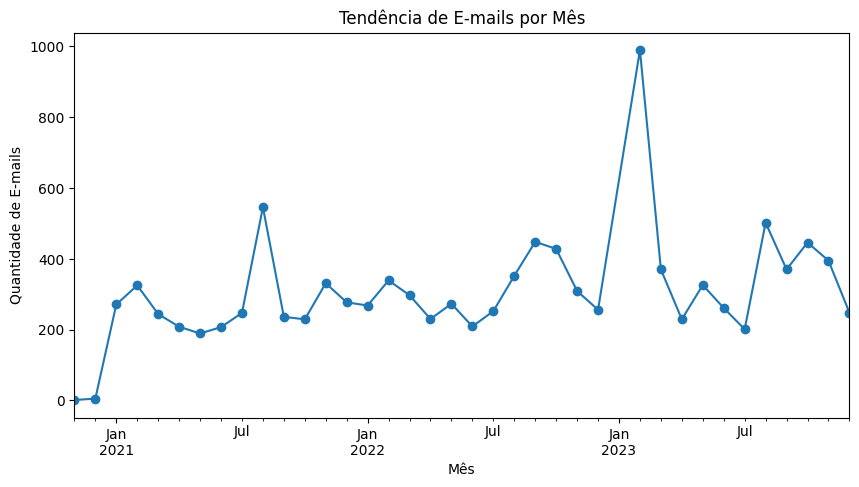

In [ ]:
# Converter a coluna de Data para datetime e extrair mês e ano
for df in [df_2021, df_2022, df_2023]:
    df['Data'] = pd.to_datetime(df['Data'])
    df['mes'] = df['Data'].dt.to_period('M')

# Contar frequência dos e-mails por mês
df_frequencia = pd.concat([df_2021, df_2022, df_2023]).groupby('mes').size()

# Plotar a tendência de e-mails recebidos por mês
import matplotlib.pyplot as plt

df_frequencia.plot(kind='line', figsize=(10, 5), marker='o', title='Tendência de E-mails por Mês')
plt.xlabel('Mês')
plt.ylabel('Quantidade de E-mails')
plt.show()

# ANÁLISE DE CORRESPONDÊNCIA ENTRE ASSUNTO E CORPO DO E-MAIL


In [ ]:
def gerar_relatorio_divergencias(df, ano):
    num_divergentes = len(df[df['processed_subject'] != df['processed_body']])
    print(f"\nRelatório de Divergências em {ano}:")
    print(f"Total de e-mails divergentes: {num_divergentes}")

# Gerar o relatório para cada ano
gerar_relatorio_divergencias(df_2021, 2021)
gerar_relatorio_divergencias(df_2022, 2022)
gerar_relatorio_divergencias(df_2023, 2023)


Relatório de Divergências em 2021:
Total de e-mails divergentes: 3289

Relatório de Divergências em 2022:
Total de e-mails divergentes: 3640

Relatório de Divergências em 2023:
Total de e-mails divergentes: 4309
